# Exploratory Data Analysis (EDA)

## Objective
- To explore the NASA CMAPSS FD001 dataset, identify patterns in engine degradation, analyze sensor behavior, detect correlations, and gain insights that will help build an accurate Remaining Useful Life (RUL) prediction model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
column_names = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for i in range(1,22):
    column_names.append(f"sensor_{i}")

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

In [3]:
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])
print("Engines:", train_df["unit_number"].nunique())

Rows: 20631
Columns: 26
Engines: 100


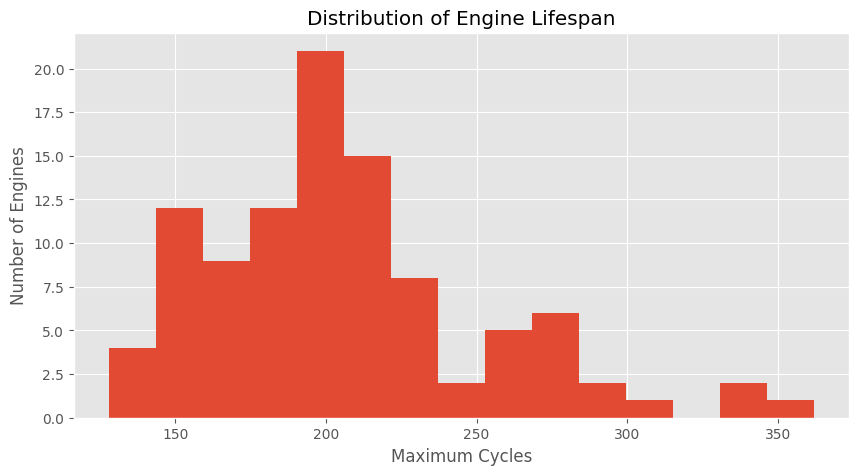

In [4]:
engine_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

plt.figure(figsize=(10,5))
plt.hist(engine_cycles, bins=15)

plt.title("Distribution of Engine Lifespan")
plt.xlabel("Maximum Cycles")
plt.ylabel("Number of Engines")

plt.show()

Most engines have varying operational lifespans before failure. This variation justifies the need for Remaining Useful Life prediction instead of relying on fixed maintenance schedules.

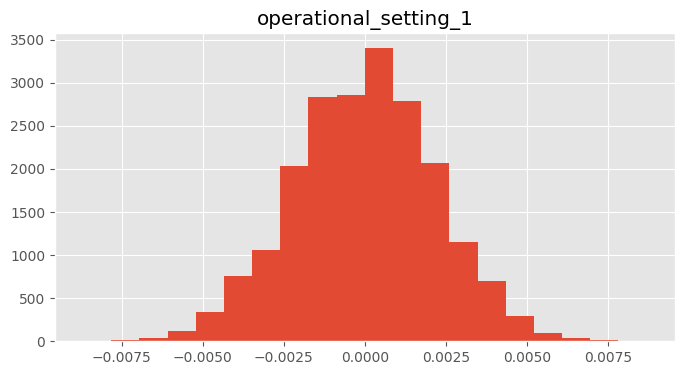

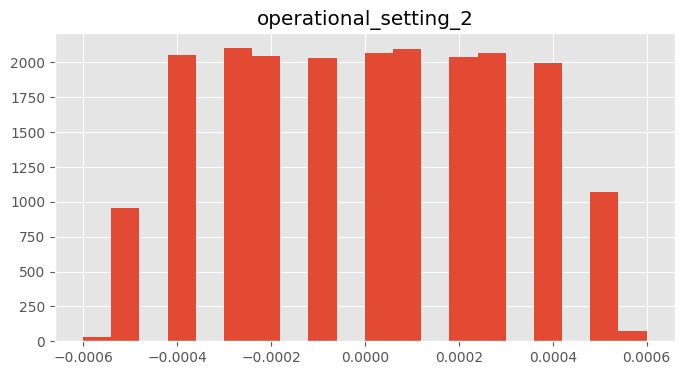

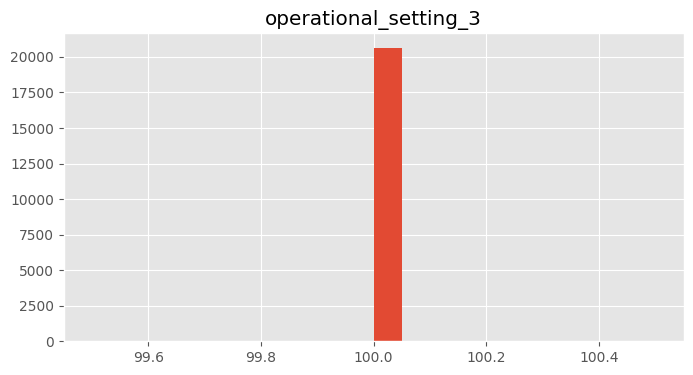

In [5]:
settings = [
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for col in settings:

    plt.figure(figsize=(8,4))

    plt.hist(train_df[col], bins=20)

    plt.title(col)

    plt.show()

Operational settings represent different engine operating conditions. These conditions may influence sensor readings and therefore affect degradation patterns.

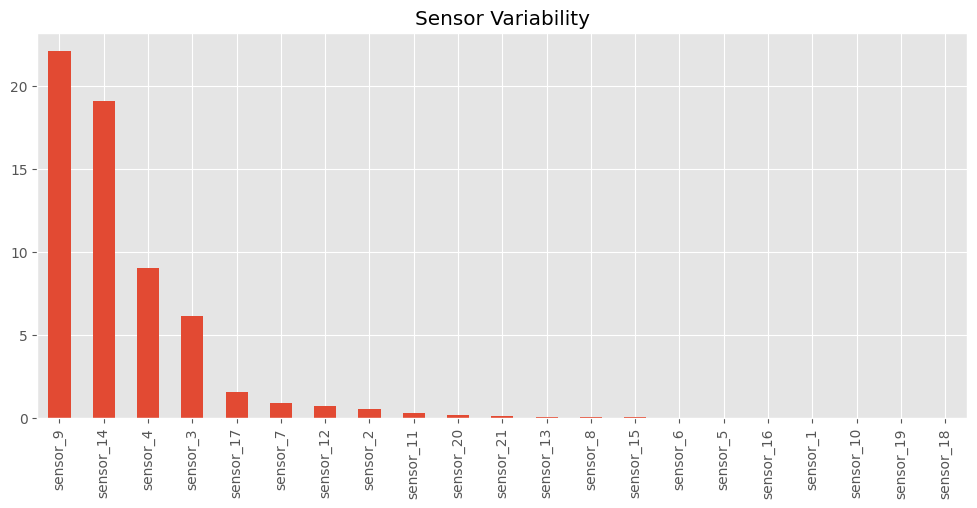

In [6]:
sensor_std = train_df.iloc[:,5:].std()

sensor_std.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Sensor Variability")

plt.show()

Sensors with very low variance may contribute little information for prediction, while highly variable sensors are more likely to capture degradation patterns.

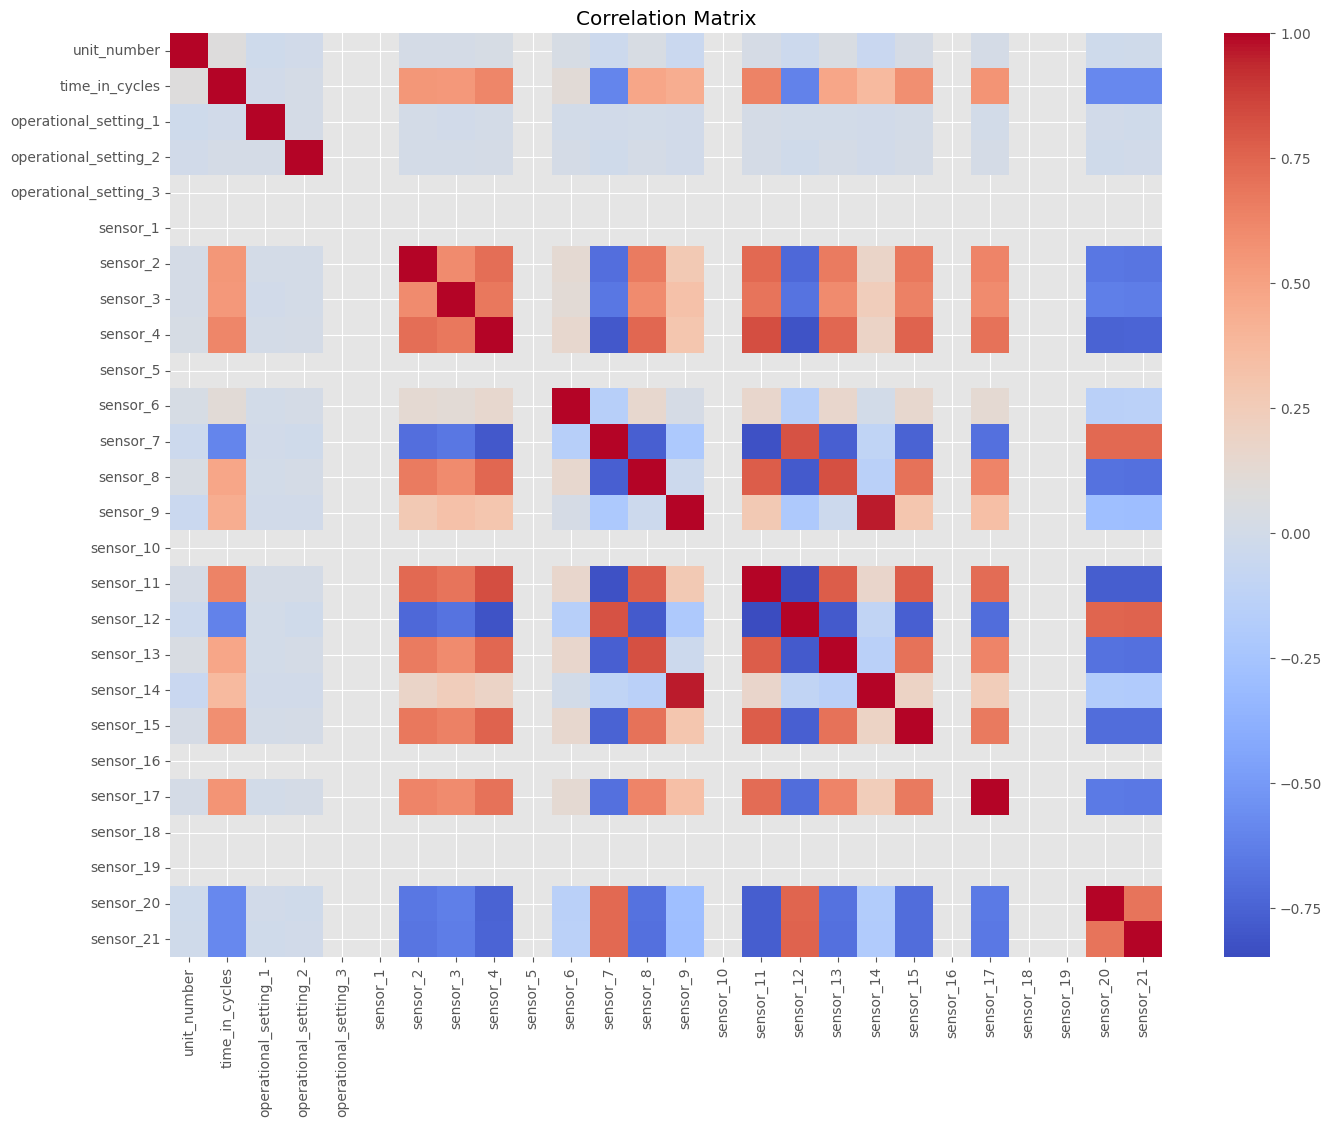

In [7]:
plt.figure(figsize=(16,12))

sns.heatmap(
    train_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix helps identify strongly related variables, redundant features, and potential multicollinearity among sensors.

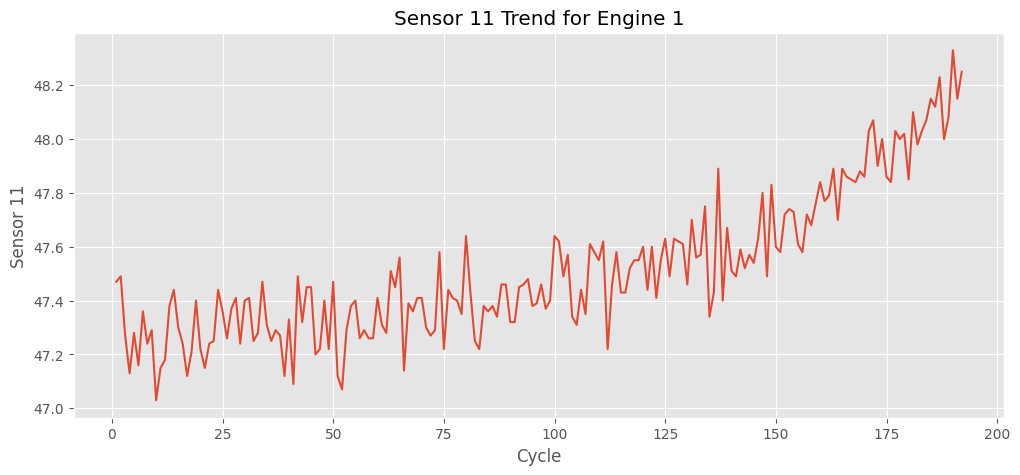

In [8]:
engine = train_df[
    train_df["unit_number"] == 1
]

plt.figure(figsize=(12,5))

plt.plot(
    engine["time_in_cycles"],
    engine["sensor_11"]
)

plt.title("Sensor 11 Trend for Engine 1")

plt.xlabel("Cycle")

plt.ylabel("Sensor 11")

plt.show()

Sensor 11 shows noticeable changes as engine cycles increase, indicating it may contain useful degradation information.

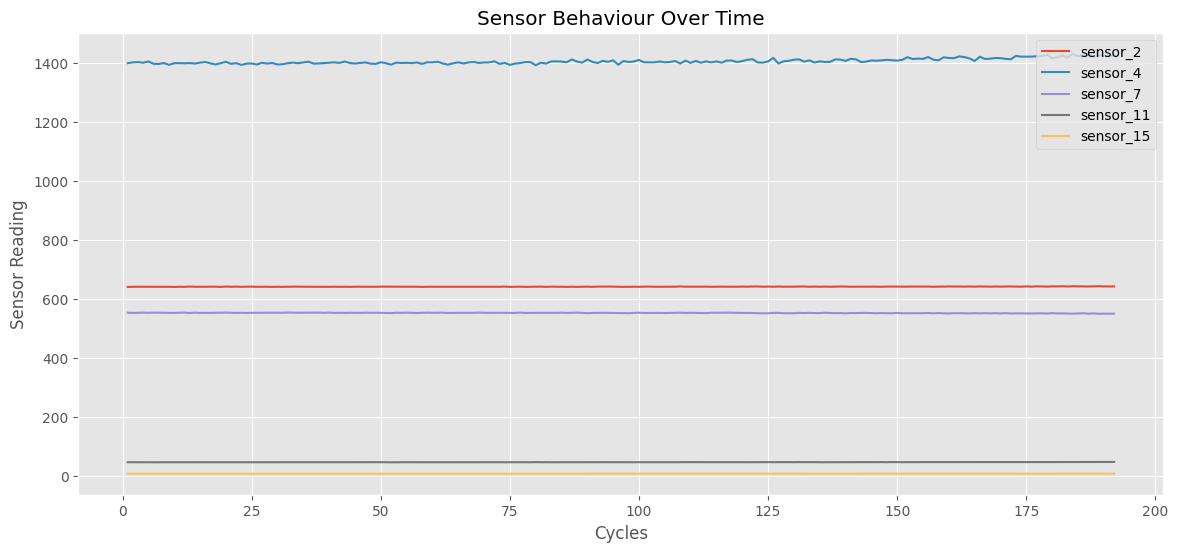

In [9]:
sensors = [
    "sensor_2",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_15"
]

engine = train_df[
    train_df["unit_number"] == 1
]

plt.figure(figsize=(14,6))

for sensor in sensors:

    plt.plot(
        engine["time_in_cycles"],
        engine[sensor],
        label=sensor
    )

plt.legend()

plt.title("Sensor Behaviour Over Time")

plt.xlabel("Cycles")

plt.ylabel("Sensor Reading")

plt.show()

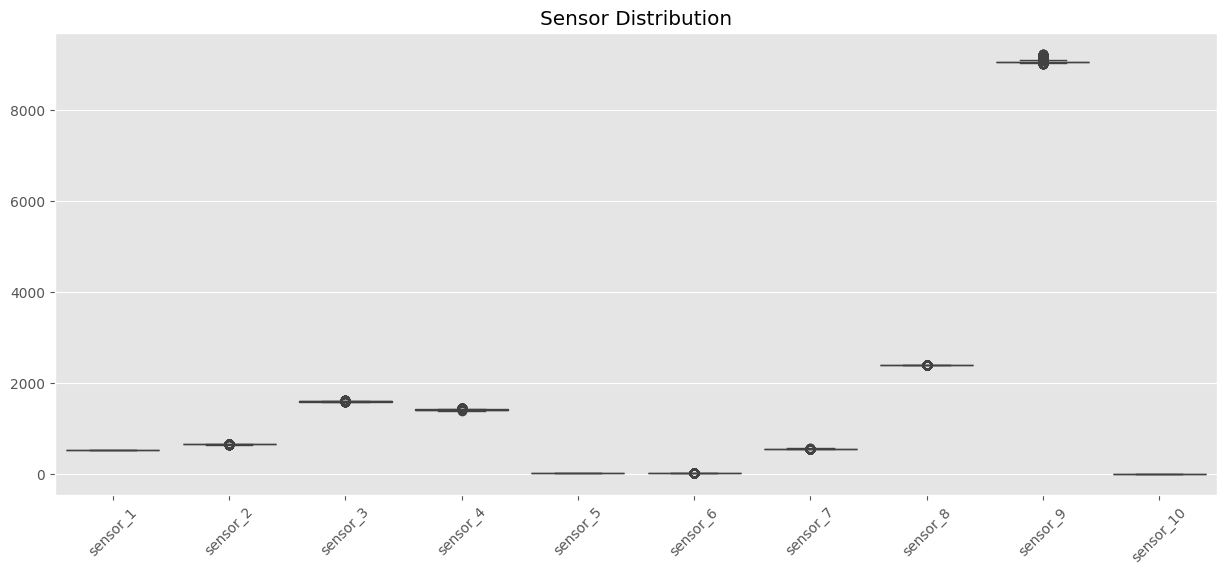

In [10]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=train_df.iloc[:,5:15]
)

plt.xticks(rotation=45)

plt.title("Sensor Distribution")

plt.show()

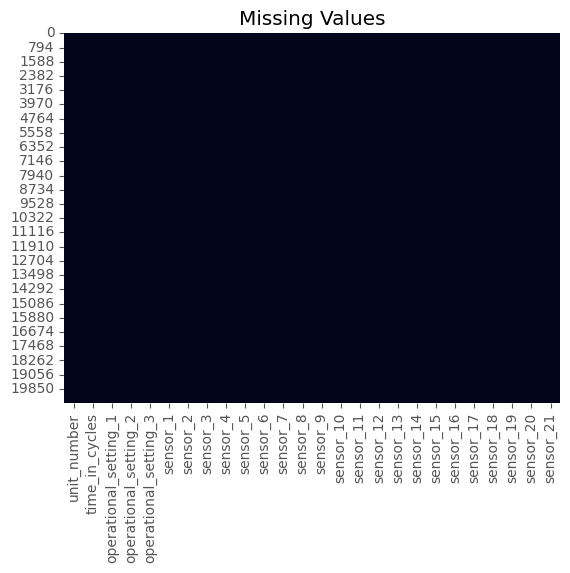

In [11]:
sns.heatmap(
    train_df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()

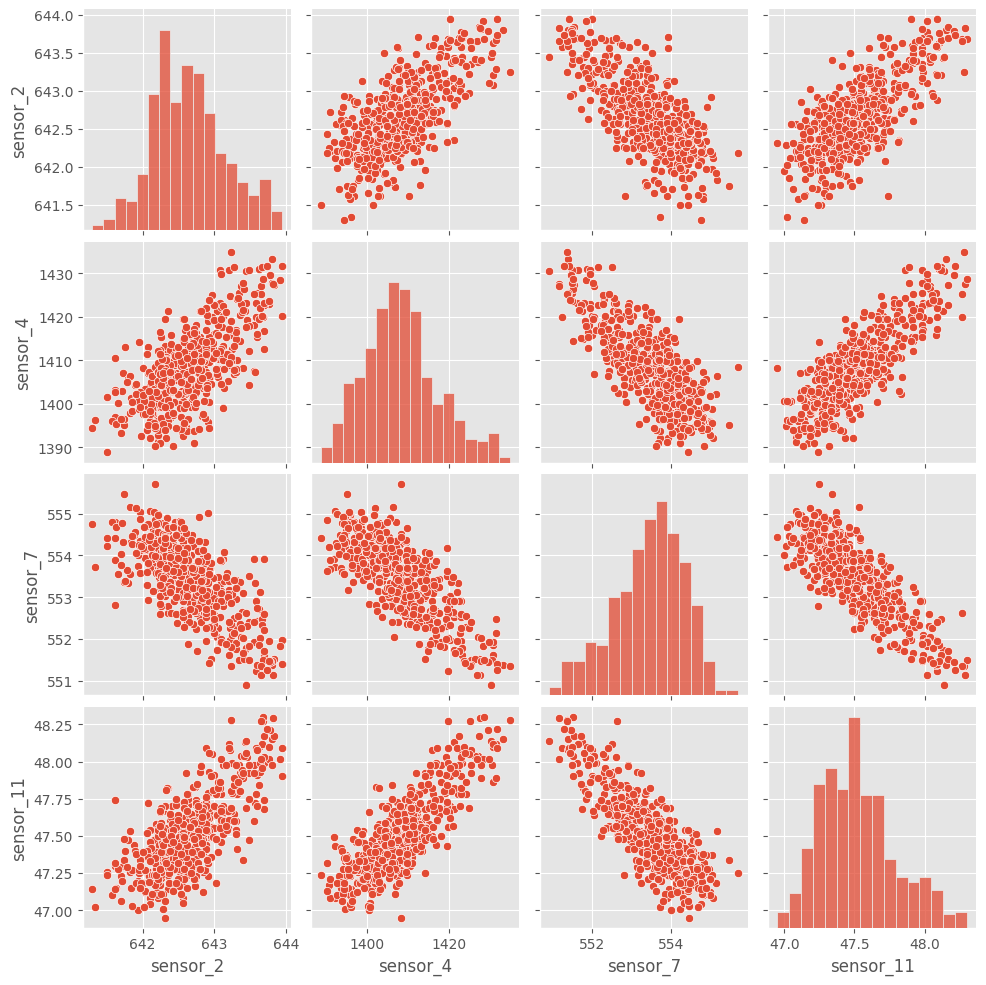

In [12]:
sample = train_df.sample(
    500,
    random_state=42
)

sns.pairplot(
    sample[
        [
            "sensor_2",
            "sensor_4",
            "sensor_7",
            "sensor_11"
        ]
    ]
)

plt.show()

## Conclusion

- Engine lifespans vary significantly across units.
- Several sensors show strong degradation trends.
- Some sensors exhibit very low variance and may not contribute meaningfully to prediction.
- Correlation analysis reveals relationships among sensors that can guide feature selection.
- The insights obtained in this notebook provide the foundation for preprocessing and feature engineering.